In [1]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt
import math 
import random

In [ ]:
file_name = 'timeExecutionForHashList.csv'
hashlist_df = pd.read_csv(file_name, header = 0, delimiter=",", decimal=".", names=['type','amountOfAttributes','runNo','executionTime'])
hashlist_df['executionTime'] = hashlist_df['executionTime'] / 1e9
hashlist_df

,type,amountOfAttributes,runNo,executionTime
0,hashlist,50,1,789400
1,hashlist,50,2,88900
2,hashlist,50,3,80400
3,hashlist,50,4,103100
4,hashlist,50,5,87200
...,...,...,...,...
49995,hashlist,250,9996,335700
49996,hashlist,250,9997,327700
49997,hashlist,250,9998,332500
49998,hashlist,250,9999,387700


In [ ]:
file_name = 'timeExecutionForMerkleTree.csv'
merkle_tree_df = pd.read_csv(file_name, header = 0, delimiter=",", decimal=".", names=['type','amountOfAttributes','runNo','executionTime'])
merkle_tree_df['executionTime'] = merkle_tree_df['executionTime'] / 1e9
merkle_tree_df

,type,amountOfAttributes,runNo,executionTime
0,merkletree,50,1,54751600
1,merkletree,50,2,2406500
2,merkletree,50,3,1612000
3,merkletree,50,4,1405900
4,merkletree,50,5,1305700
...,...,...,...,...
49995,merkletree,250,9996,500300
49996,merkletree,250,9997,422900
49997,merkletree,250,9998,409100
49998,merkletree,250,9999,349900


In [4]:
df = pd.concat([merkle_tree_df, hashlist_df])

Text(0.5, 0, 'Execution time (ms)')

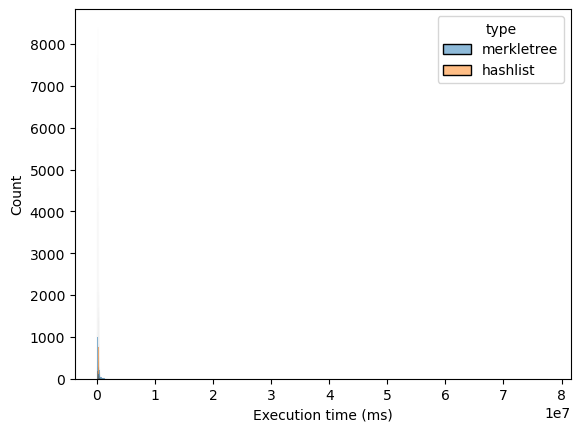

In [ ]:
sns.histplot(data=df, hue="type", x="executionTime")
plt.xlabel("Execution time (s)")

Text(0.5, 0, 'Amount of attributes')

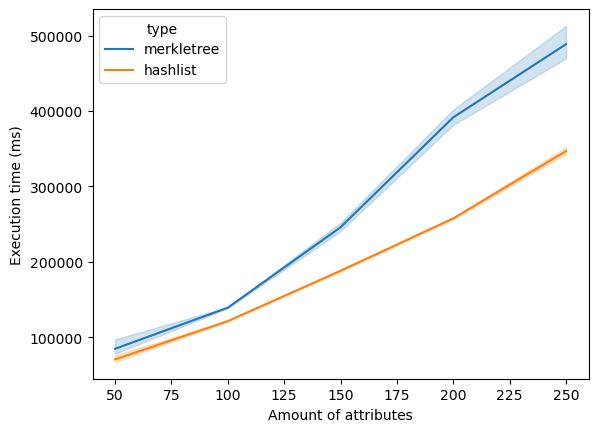

In [ ]:
sns.lineplot(data=df, hue="type", x='amountOfAttributes', y='executionTime')
plt.ylabel("Execution time (s)")
plt.xlabel("Amount of attributes")


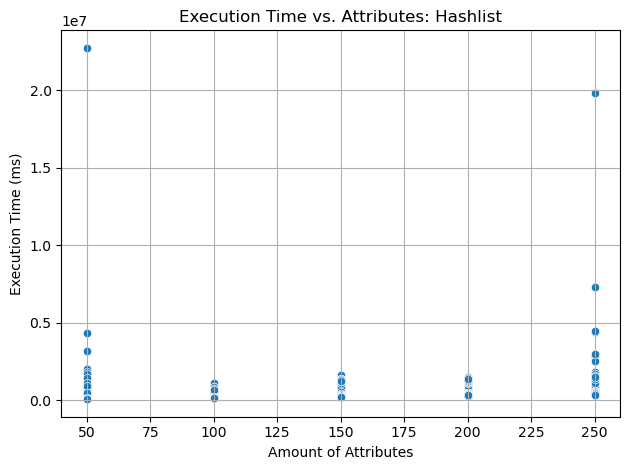

In [7]:
sns.scatterplot(data=hashlist_df, x='amountOfAttributes', y='executionTime')
plt.xlabel("Amount of Attributes")
plt.ylabel("Execution Time (ms)")
plt.title("Execution Time vs. Attributes: Hashlist")
plt.grid(True)
plt.tight_layout()
plt.show()


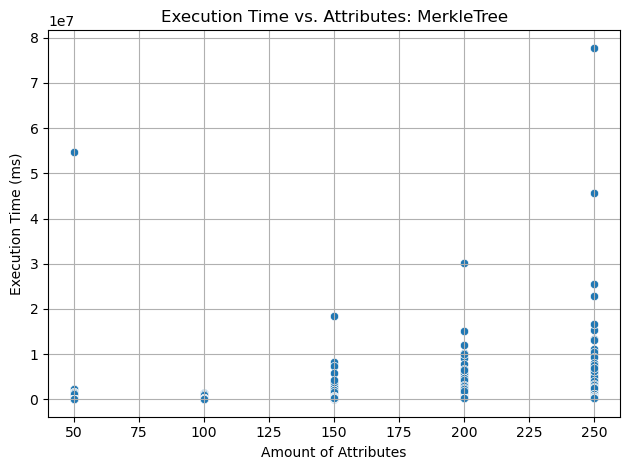

In [8]:
sns.scatterplot(data=merkle_tree_df, x='amountOfAttributes', y='executionTime')
plt.xlabel("Amount of Attributes")
plt.ylabel("Execution Time (ms)")
plt.title("Execution Time vs. Attributes: MerkleTree")
plt.grid(True)
plt.tight_layout()
plt.show()


C:\Users\Moosdorf\AppData\Local\Temp\ipykernel_27140\3765723069.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  means = hashlist_df.groupby('bin')['executionTime'].mean()


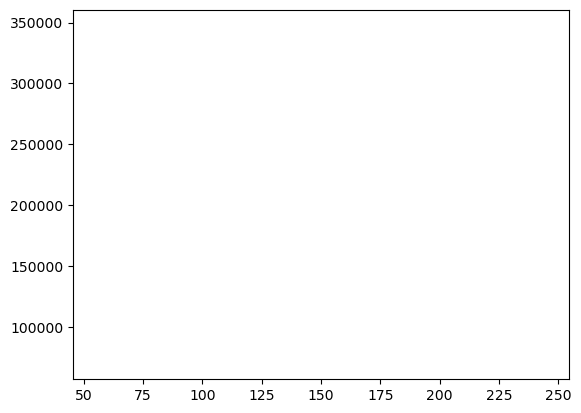

In [9]:
hashlist_df['bin'] = pd.cut(hashlist_df['amountOfAttributes'], bins=20)
means = hashlist_df.groupby('bin')['executionTime'].mean()
bin_centers = [b.mid for b in means.index]
plt.plot(bin_centers, means.values, color='green', linewidth=2)

C:\Users\Moosdorf\AppData\Local\Temp\ipykernel_27140\2023077030.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  means = merkle_tree_df.groupby('bin')['executionTime'].mean()


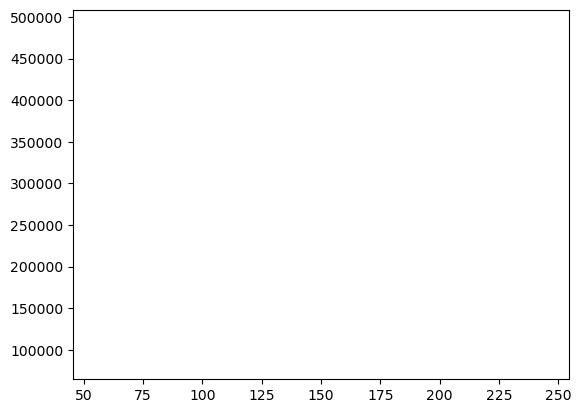

In [10]:
merkle_tree_df['bin'] = pd.cut(merkle_tree_df['amountOfAttributes'], bins=20)
means = merkle_tree_df.groupby('bin')['executionTime'].mean()
bin_centers = [b.mid for b in means.index]
plt.plot(bin_centers, means.values, color='red', linewidth=2)